In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


bay_area_data = pd.read_csv('Bay_Area_Data.csv')
bay_area_data



,Date,Unnamed: 0,Census Tract,Total Population,California County,ZIP,Nearby City \n(to help approximate location only),Longitude,Latitude,DRAFT CES 4.0 Score,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,2023-12-27,162,6001407300,2440,Alameda,94601,Oakland,-122.210924,37.762179,64.58,...,85.55,56.9,86.61,12.8,91.61,31.5,91.92,84.00,8.71,95.83
1,2023-01-29,200,6001408800,7054,Alameda,94621,Oakland,-122.196942,37.758804,63.19,...,68.17,66.6,94.40,10.9,85.81,28.2,85.62,90.78,9.41,99.21
2,2023-04-01,217,6001409000,3904,Alameda,94621,Oakland,-122.221368,37.720011,62.67,...,83.68,41.6,68.17,8.0,69.34,23.9,74.50,82.02,8.50,94.31
3,2023-08-08,248,6095250701,3595,Solano,94590,Vallejo,-122.244902,38.090042,61.81,...,70.92,42.7,69.67,10.9,85.81,25.7,79.85,82.95,8.60,95.08
4,2023-12-13,331,6001409100,2327,Alameda,94603,Oakland,-122.183500,37.732326,59.77,...,NaN,41.4,67.84,11.5,87.89,38.4,97.66,87.17,9.04,97.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1576,2023-02-10,8020,6075980900,272,San Francisco,94124,San Francisco,-122.389477,37.746286,NaN,...,NaN,24.3,40.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1577,2023-06-20,8024,6081984300,0,San Mateo,94128,San Francisco,-122.376861,37.614758,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1578,2023-12-31,8028,6085511608,3238,Santa Clara,94305,Stanford,-122.177218,37.429257,NaN,...,NaN,36.3,60.59,8.9,75.65,NaN,NaN,NaN,NaN,NaN
1579,2023-05-20,8029,6095253000,6435,Solano,95687,Vacaville,-121.978785,38.320656,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
bay_area_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 60 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Date                                              1581 non-null   object 
 1   Unnamed: 0                                        1581 non-null   int64  
 2   Census Tract                                      1581 non-null   int64  
 3    Total Population                                 1581 non-null   int64  
 4   California County                                 1581 non-null   object 
 5   ZIP                                               1581 non-null   int64  
 6   Nearby City 
(to help approximate location only)  1581 non-null   object 
 7   Longitude                                         1581 non-null   float64
 8   Latitude                                          1581 non-null   float64
 9   DRAFT CES 4.0 Score

In [8]:
bay_area_data.isnull().sum()

,0
Date,0
Unnamed: 0,0
Census Tract,0
Total Population,0
California County,0
ZIP,0
Nearby City \n(to help approximate location only),0
Longitude,0
Latitude,0
DRAFT CES 4.0 Score,13


In [10]:
#Fill missing values in 'Asthma' and 'Cardiovascular Disease' columns with their median values
# This approach ensures that missing values do not affect the analysis while maintaining central tendencies
bay_area_data['Asthma'] = bay_area_data['Asthma'].fillna(bay_area_data['Asthma'].median())
bay_area_data['Cardiovascular Disease'] = bay_area_data['Cardiovascular Disease'].fillna(
    bay_area_data['Cardiovascular Disease'].median()
)

In [11]:
bay_area_data['California County'] = bay_area_data['California County'].fillna(bay_area_data['California County'].mode()[0])

In [12]:
# Drop rows with missing values in 'DRAFT CES 4.0 Score'
# This column is critical for analysis, so rows with missing values are removed
bay_area_data = bay_area_data.dropna(subset=['DRAFT CES 4.0 Score'])

In [13]:
bay_area_data['Date'] = pd.to_datetime(bay_area_data['Date'])

/tmp/ipykernel_2915/514093935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bay_area_data['Date'] = pd.to_datetime(bay_area_data['Date'])


In [14]:
#filtering the columns and keeping the ones that we need from the datatset.
columns_to_keep = [
    'Date','California County', 'Nearby City \n(to help approximate location only)',
    'Longitude', 'Latitude', 'PM2.5', 'Ozone','Ozone Pctl','Diesel PM', 'Asthma', 'Asthma Pctl',
    'Cardiovascular Disease','Cardiovascular Disease Pctl','DRAFT CES 4.0 Score', 'Pollution Burden Score'
]

# Filter the dataset again to include these columns
bay_area_data = bay_area_data[columns_to_keep]
bay_area_data

,Date,California County,Nearby City \n(to help approximate location only),Longitude,Latitude,PM2.5,Ozone,Ozone Pctl,Diesel PM,Asthma,Asthma Pctl,Cardiovascular Disease,Cardiovascular Disease Pctl,DRAFT CES 4.0 Score,Pollution Burden Score
0,2023-12-27,Alameda,Oakland,-122.210924,37.762179,9.082865,0.029,4.38,0.633,113.30,95.29,12.41,49.83,64.58,7.42
1,2023-01-29,Alameda,Oakland,-122.196942,37.758804,8.834295,0.029,5.00,0.321,194.40,99.68,21.04,90.47,63.19,6.71
2,2023-04-01,Alameda,Oakland,-122.221368,37.720011,8.709957,0.029,4.77,0.562,173.63,99.54,15.26,68.13,62.67,7.37
3,2023-08-08,Solano,Vallejo,-122.244902,38.090042,9.095673,0.034,11.76,0.411,199.35,99.81,21.22,91.55,61.81,7.19
4,2023-12-13,Alameda,Oakland,-122.183500,37.732326,8.499142,0.030,5.71,0.629,226.34,99.94,19.11,84.58,59.77,6.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,2023-09-25,Marin,Mill Valley,-122.558505,37.910441,8.287859,0.029,5.64,0.021,15.13,3.89,6.73,6.41,1.55,2.51
1564,2023-07-30,Contra Costa,Moraga,-122.095336,37.845069,8.592202,0.034,12.45,0.031,15.52,4.34,6.79,6.67,1.53,2.39
1565,2023-05-15,Contra Costa,Orinda,-122.168419,37.879503,8.818447,0.032,9.01,0.103,13.12,2.29,5.70,2.48,1.50,2.88
1566,2023-11-27,Contra Costa,Lafayette,-122.105108,37.868286,8.689217,0.034,12.22,0.030,18.71,7.49,6.47,5.30,1.27,2.84


In [15]:
bay_area_data.info()
bay_area_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1568 entries, 0 to 1567
Data columns (total 15 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Date                                              1568 non-null   datetime64[ns]
 1   California County                                 1568 non-null   object        
 2   Nearby City 
(to help approximate location only)  1568 non-null   object        
 3   Longitude                                         1568 non-null   float64       
 4   Latitude                                          1568 non-null   float64       
 5   PM2.5                                             1568 non-null   float64       
 6   Ozone                                             1568 non-null   float64       
 7   Ozone Pctl                                        1568 non-null   float64       
 8   Diesel PM                        

,Date,California County,Nearby City \n(to help approximate location only),Longitude,Latitude,PM2.5,Ozone,Ozone Pctl,Diesel PM,Asthma,Asthma Pctl,Cardiovascular Disease,Cardiovascular Disease Pctl,DRAFT CES 4.0 Score,Pollution Burden Score
0,2023-12-27,Alameda,Oakland,-122.210924,37.762179,9.082865,0.029,4.38,0.633,113.30,95.29,12.41,49.83,64.58,7.42
1,2023-01-29,Alameda,Oakland,-122.196942,37.758804,8.834295,0.029,5.00,0.321,194.40,99.68,21.04,90.47,63.19,6.71
2,2023-04-01,Alameda,Oakland,-122.221368,37.720011,8.709957,0.029,4.77,0.562,173.63,99.54,15.26,68.13,62.67,7.37
3,2023-08-08,Solano,Vallejo,-122.244902,38.090042,9.095673,0.034,11.76,0.411,199.35,99.81,21.22,91.55,61.81,7.19
4,2023-12-13,Alameda,Oakland,-122.183500,37.732326,8.499142,0.030,5.71,0.629,226.34,99.94,19.11,84.58,59.77,6.61


In [33]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Scale specific columns and update them using .loc
bay_area_data.loc[:, ['PM2.5', 'Ozone', 'Diesel PM']] = scaler.fit_transform(
    bay_area_data[['PM2.5', 'Ozone', 'Diesel PM']]
)


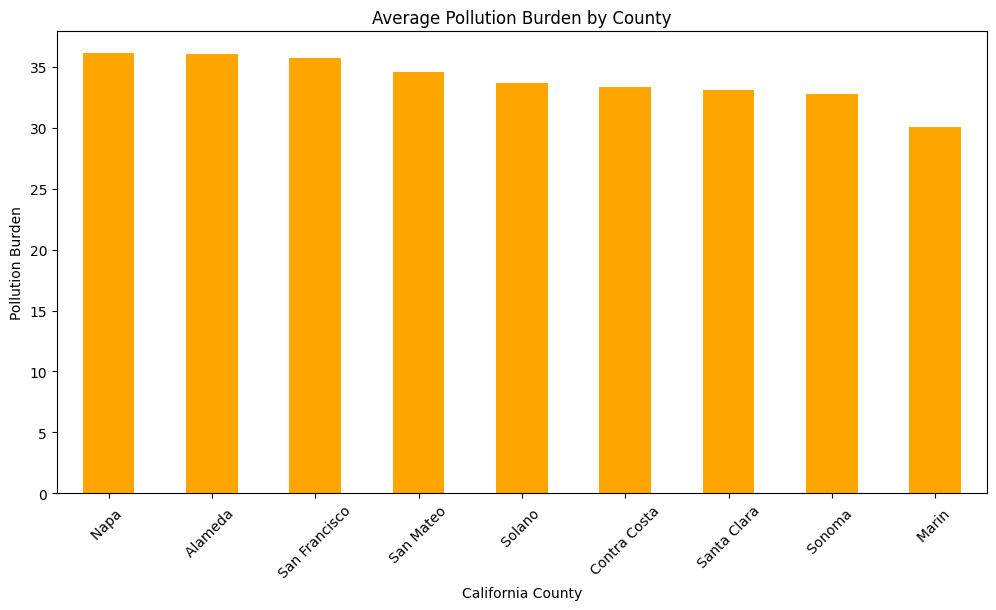

In [34]:
# Clean column names by stripping whitespace
bay_area_data.columns = bay_area_data.columns.str.strip()

# Calculate the average pollution burden by county
pollution_hotspots = bay_area_data.groupby('California County')['Pollution Burden'].mean().sort_values(ascending=False)

# Visualize hotspots
pollution_hotspots.plot(kind='bar', figsize=(12, 6), color='orange')
plt.title('Average Pollution Burden by County')
plt.ylabel('Pollution Burden')
plt.xlabel('California County')
plt.xticks(rotation=45)
plt.show()


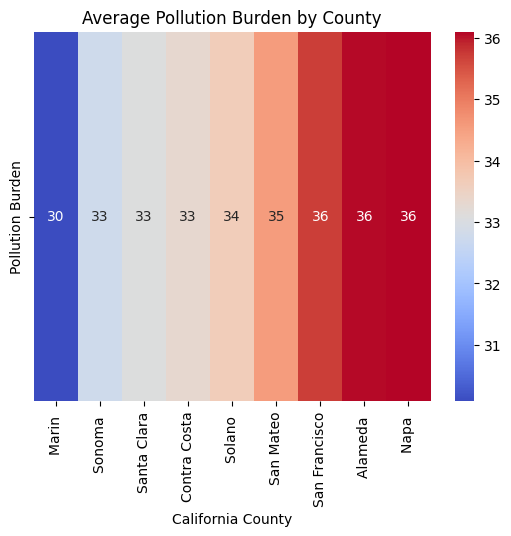

In [32]:
import matplotlib.pyplot as plt


# Heatmap of Pollution Burden by County
pollution_by_county = bay_area_data.groupby('California County')['Pollution Burden'].mean().sort_values()
sns.heatmap(pollution_by_county.to_frame().T, annot=True, cmap="coolwarm")
plt.title('Average Pollution Burden by County')
plt.show()

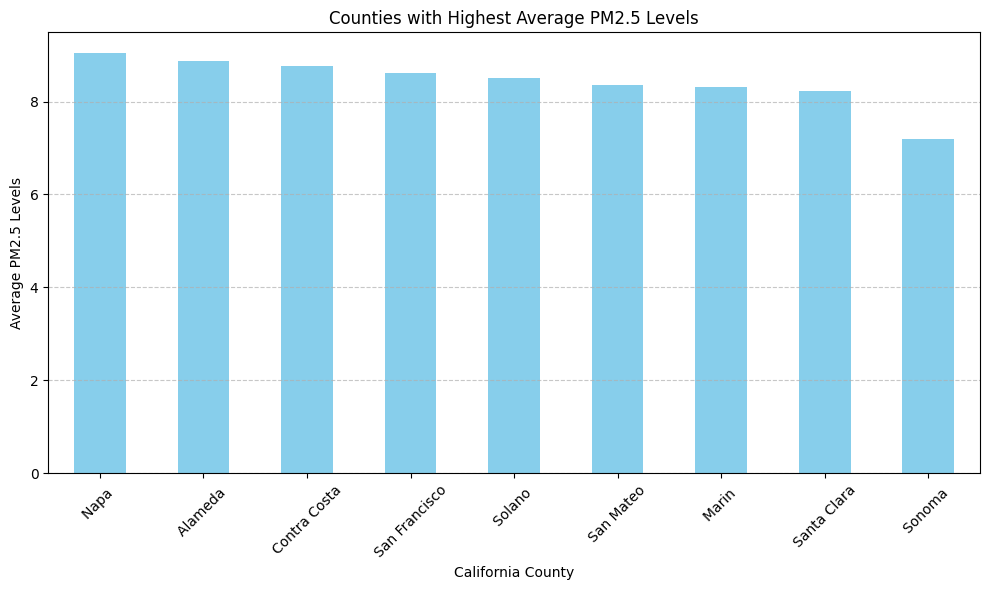

In [27]:
# Aggregate pollution data by county
county_pollution = bay_area_data.groupby('California County')[['PM2.5', 'Ozone', 'Diesel PM']].mean()

# Sort by PM2.5 levels (highest pollution areas)
top_polluted_counties = county_pollution.sort_values(by='PM2.5', ascending=False)

# Plot the top polluted counties
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_polluted_counties['PM2.5'].plot(kind='bar', color='skyblue')
plt.title("Counties with Highest Average PM2.5 Levels")
plt.ylabel("Average PM2.5 Levels")
plt.xlabel("California County")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

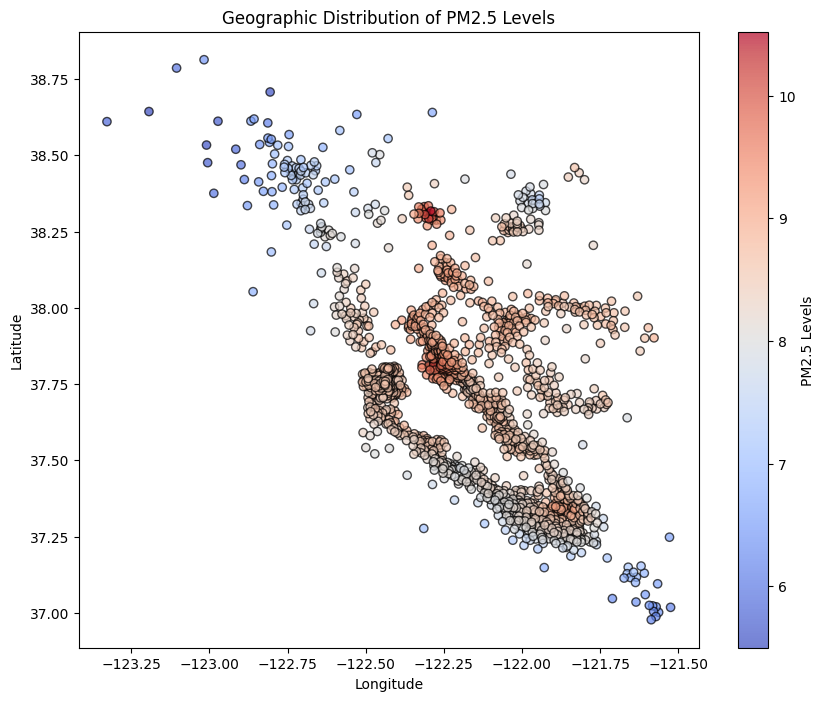

In [28]:
# Scatter plot for PM2.5 levels
plt.figure(figsize=(10, 8))
plt.scatter(
    bay_area_data['Longitude'],
    bay_area_data['Latitude'],
    c=bay_area_data['PM2.5'], cmap='coolwarm', alpha=0.7, edgecolor='k'
)
plt.colorbar(label='PM2.5 Levels')
plt.title("Geographic Distribution of PM2.5 Levels")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Convert your DataFrame to a GeoDataFrame
bay_area_data = bay_area_data.dropna(subset=['Latitude', 'Longitude'])  # Drop rows with missing coordinates
gdf = gpd.GeoDataFrame(
    bay_area_data,
    geometry=gpd.points_from_xy(bay_area_data['Longitude'], bay_area_data['Latitude'])
)

# Load a Bay Area shapefile or a world boundary map (ensure it's in WGS 84 projection)
bay_area_boundary = gpd.read_file("path_to_bay_area_shapefile.shp")  # Replace with actual shapefile path

# Reproject shapefile and GeoDataFrame to the same CRS if needed
gdf = gdf.set_crs("EPSG:4326")  # WGS 84
bay_area_boundary = bay_area_boundary.to_crs(gdf.crs)

# Plot data on the map
fig, ax = plt.subplots(figsize=(10, 10))
bay_area_boundary.plot(ax=ax, color='lightgrey', edgecolor='black')  # Base map
gdf.plot(
    ax=ax,
    column='PM2.5',  # Use PM2.5 levels for coloring
    cmap='coolwarm',
    legend=True,
    legend_kwds={'label': "PM2.5 Levels"},
    markersize=10,
    alpha=0.7
)
plt.title("Geographic Distribution of PM2.5 Levels in the Bay Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

DataSourceError: path_to_bay_area_shapefile.shp: No such file or directory

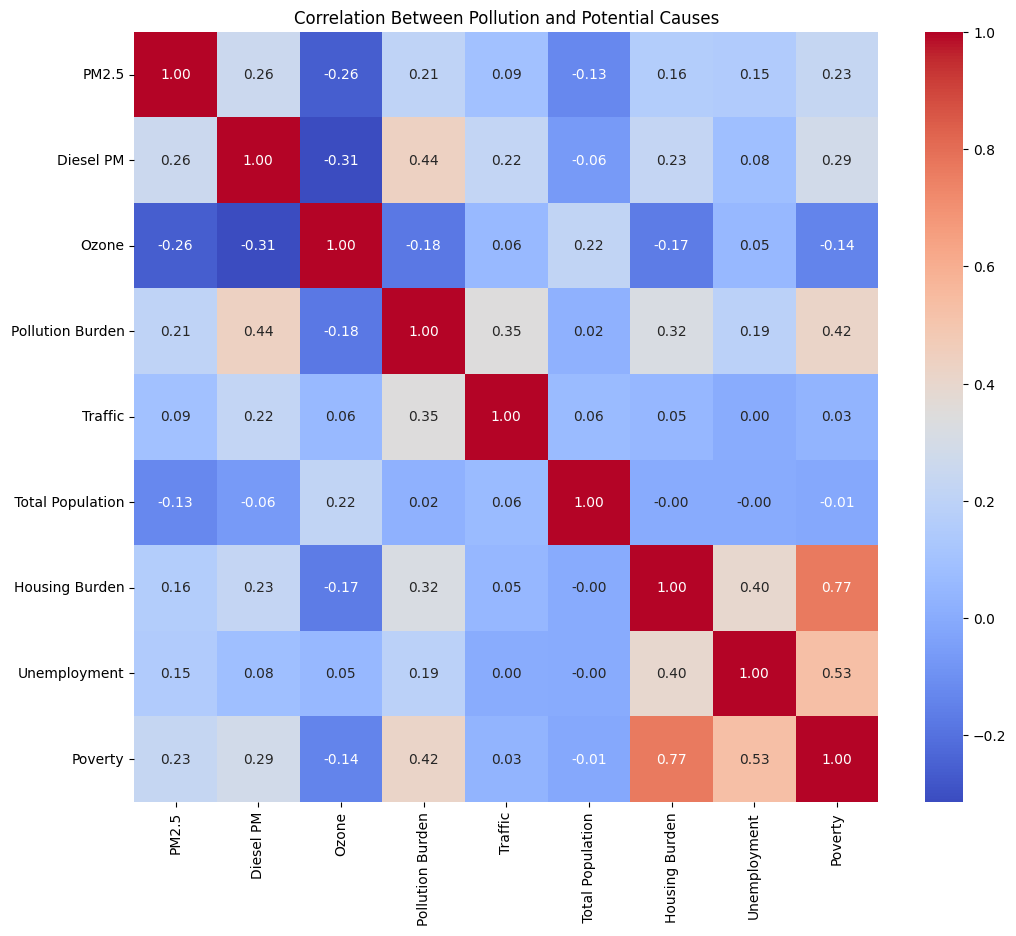

Strongest Correlations with Pollution Metrics:
              PM2.5  Diesel PM     Ozone  Pollution Burden
PM2.5      1.000000   0.257529  0.261387          0.209490
Ozone      0.261387   0.313488  1.000000          0.175762
Diesel PM  0.257529   1.000000  0.313488          0.440263


In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the dataset
bay_area_data = pd.read_csv("Bay_Area_Data.csv")

# Select relevant columns for analyzing causes of pollution
causes_columns = [
    'PM2.5', 'Diesel PM', 'Ozone', 'Pollution Burden',
    'Traffic', ' Total Population', 'Housing Burden', 'Unemployment', 'Poverty'
]

# Subset the data and drop missing values
pollution_causes_data = bay_area_data[causes_columns].dropna()

# Calculate the correlation matrix to identify relationships
correlation_matrix = pollution_causes_data.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Pollution and Potential Causes")
plt.show()

# Summarize the strongest correlations with pollution metrics
strong_correlations = correlation_matrix[['PM2.5', 'Diesel PM', 'Ozone', 'Pollution Burden']].abs()
strongest_correlations = strong_correlations.nlargest(3, ['PM2.5', 'Diesel PM', 'Ozone', 'Pollution Burden'])

print("Strongest Correlations with Pollution Metrics:")
print(strongest_correlations)


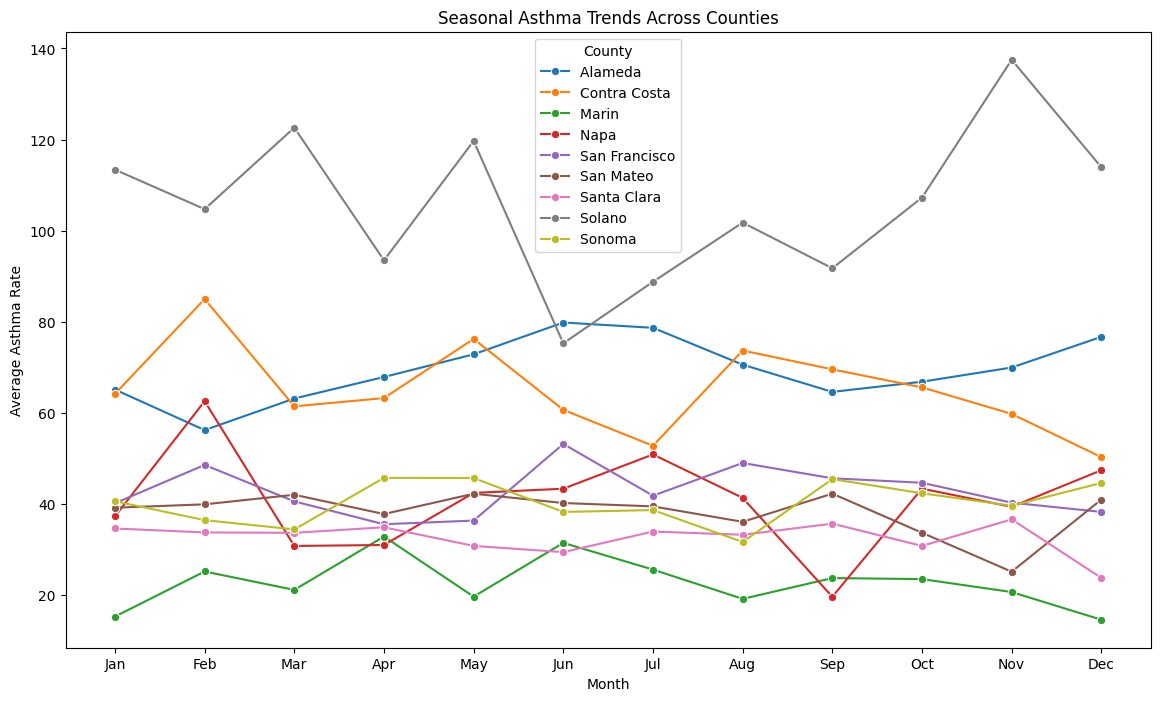

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Date' column is converted to datetime format
bay_area_data['Date'] = pd.to_datetime(bay_area_data['Date'])

# Extract the month from the date
bay_area_data['Month'] = bay_area_data['Date'].dt.month

# Group by Month and County, then calculate mean Asthma rates
seasonal_trends = bay_area_data.groupby(['California County', 'Month'])['Asthma'].mean().reset_index()

# Visualize seasonal asthma trends
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=seasonal_trends,
    x='Month',
    y='Asthma',
    hue='California County',
    marker='o'
)
plt.title('Seasonal Asthma Trends Across Counties')
plt.xlabel('Month')
plt.ylabel('Average Asthma Rate')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='County')
plt.show()


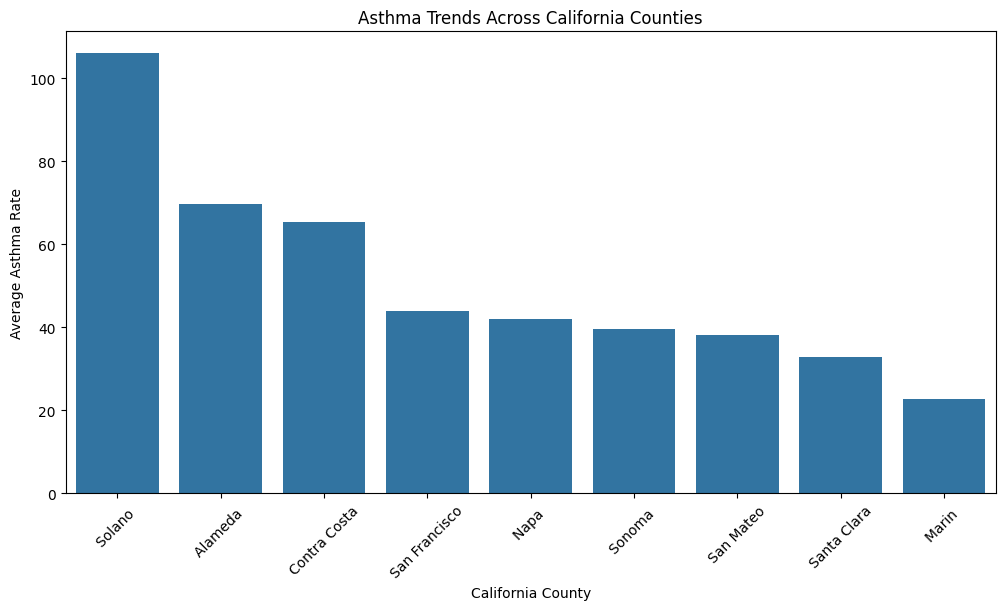

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
sns.barplot(
    x='California County',
    y='Asthma',
    data=bay_area_data,
    errorbar=None,
    order=bay_area_data.groupby('California County')['Asthma'].mean().sort_values(ascending=False).index,
)
plt.title('Asthma Trends Across California Counties')
plt.ylabel('Average Asthma Rate')
plt.xlabel('California County')
plt.xticks(rotation=45)
plt.show()


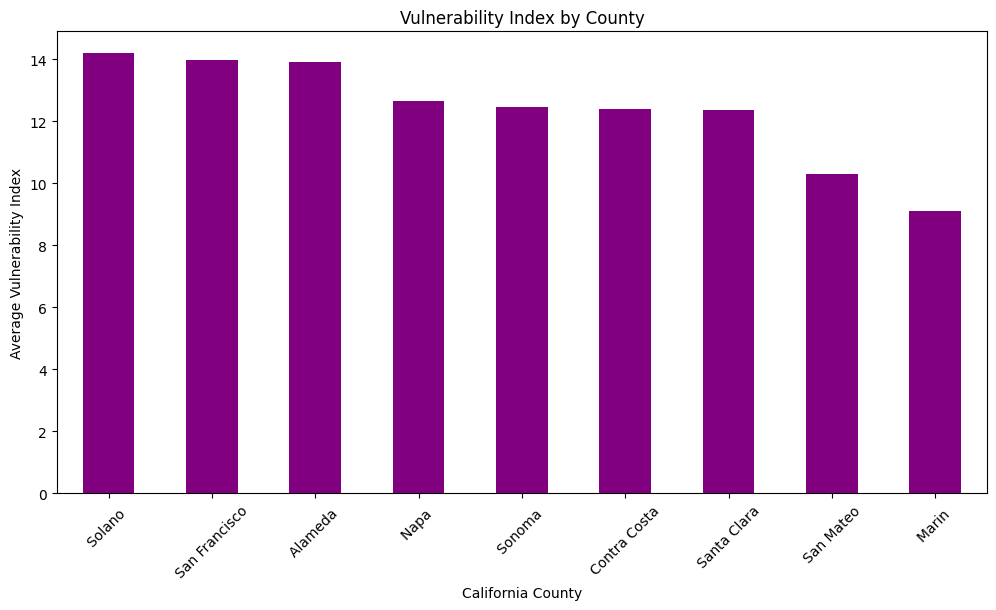

In [24]:
# Create a composite vulnerability index
bay_area_data['Vulnerability Index'] = (
    bay_area_data['Poverty'] * 0.4 +
    bay_area_data['Unemployment'] * 0.3 +
    bay_area_data['Linguistic Isolation'] * 0.3
)

# Rank counties by vulnerability
vulnerability_summary = bay_area_data.groupby('California County')['Vulnerability Index'].mean().sort_values(ascending=False)

# Visualize
vulnerability_summary.plot(kind='bar', figsize=(12, 6), color='purple')
plt.title('Vulnerability Index by County')
plt.ylabel('Average Vulnerability Index')
plt.xlabel('California County')
plt.xticks(rotation=45)
plt.show()


In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Load the dataset
bay_area_data = pd.read_csv("Bay_Area_Data.csv")

# Preparing the dataset for regional health risk prediction
# Features: Pollution metrics; Target: Health metrics (Asthma as an example)
features = ['PM2.5', 'Ozone', 'Diesel PM', 'Pollution Burden']
target = 'Asthma'

# Dropping rows with missing values
regional_data = bay_area_data.dropna(subset=features + [target])

X = regional_data[features]
y = regional_data[target]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model for prediction
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Display model evaluation metrics
evaluation_results = {
    "R2 Score": r2,
    "Mean Absolute Error": mae
}

# Regional predictions for future health risks
regional_predictions = pd.DataFrame({
    'California County': regional_data['California County'].iloc[X_test.index],
    'Actual Asthma': y_test.values,
    'Predicted Asthma': y_pred
}).reset_index(drop=True)

# Output results
print("Evaluation Results:", evaluation_results)
print("\nRegional Predictions (Sample):")
print(regional_predictions.head())


Evaluation Results: {'R2 Score': 0.29712326380969434, 'Mean Absolute Error': 18.608327215189874}

Regional Predictions (Sample):
  California County  Actual Asthma  Predicted Asthma
0       Santa Clara          36.08           34.5843
1          Alameda           64.70           39.7453
2       Santa Clara          13.09           11.7387
3       Santa Clara          36.83           27.4701
4           Solano           83.11           89.5350


In [26]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Load the dataset
bay_area_data = pd.read_csv("Bay_Area_Data.csv")

# Preprocessing: Extract temporal features and target
bay_area_data['Date'] = pd.to_datetime(bay_area_data['Date'])
bay_area_data['Month'] = bay_area_data['Date'].dt.month
bay_area_data['Year'] = bay_area_data['Date'].dt.year

# Features and Target
features = ['PM2.5', 'Ozone', 'Diesel PM', 'Pollution Burden', 'Month', 'Year']
target = 'Asthma'

# Drop rows with missing values
forecast_data = bay_area_data.dropna(subset=features + [target])

X = forecast_data[features]
y = forecast_data[target]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
gbr_model.fit(X_train, y_train)

# Making predictions
y_pred = gbr_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Model Performance:")
print(f"R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

# Forecasting future health risks (Example for next year)
future_year = 2025
future_months = list(range(1, 13))
future_data = pd.DataFrame({
    'PM2.5': np.mean(X['PM2.5']),  # Using average pollution level
    'Ozone': np.mean(X['Ozone']),
    'Diesel PM': np.mean(X['Diesel PM']),
    'Pollution Burden': np.mean(X['Pollution Burden']),
    'Month': future_months,
    'Year': [future_year] * 12
})

# Predict future asthma rates
future_predictions = gbr_model.predict(future_data)

# Display future predictions
forecast_results = pd.DataFrame({
    'Month': future_months,
    'Year': [future_year] * 12,
    'Predicted Asthma Rate': future_predictions
})
print("\nForecasted Health Risks for 2025:")
print(forecast_results)

Model Performance:
R2 Score: 0.32
Mean Absolute Error: 19.72

Forecasted Health Risks for 2025:
    Month  Year  Predicted Asthma Rate
0       1  2025              45.394090
1       2  2025              49.332073
2       3  2025              49.332073
3       4  2025              49.332073
4       5  2025              49.332073
5       6  2025              49.332073
6       7  2025              49.332073
7       8  2025              49.332073
8       9  2025              49.332073
9      10  2025              49.332073
10     11  2025              49.332073
11     12  2025              49.332073
